In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mango Dataset.zip to Mango Dataset.zip


In [3]:
import zipfile

zip_path = "Mango Dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("mango_Dataset")

print("Extracted successfully!")

Extracted successfully!


In [4]:
import os

print(os.listdir("mango_Dataset"))

['UnRipe', 'OverRipe', 'Ripe']


In [6]:
dataset_path = "mango_dataset"


MANGO IMAGE COUNT:
OverRipe: 21
Ripe: 43
UnRipe: 911
Total Images: 975

MANGO RIPENESS DETECTION
1. Train Model
2. Predict Image
Enter choice (1/2): 1
Found 781 images belonging to 3 classes.
Found 194 images belonging to 3 classes.
Detected classes for model: ['OverRipe', 'Ripe', 'UnRipe']
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9321 - loss: 0.2240 - val_accuracy: 0.9433 - val_loss: 0.2284
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9706 - loss: 0.1037 - val_accuracy: 0.9536 - val_loss: 0.2619
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9834 - loss: 0.0814 - val_accuracy: 0.9485 - val_loss: 0.2847
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9834 - loss: 0.0849 - val_accuracy: 0.9485 - val_loss: 0.2654
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9757 - loss: 0.0947 - val_accuracy: 0.9485 - val_loss: 0.2946
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9744 - loss: 

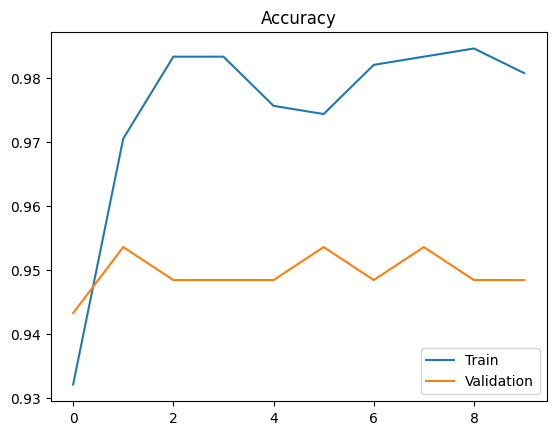

✅ Model trained and saved!


In [15]:
# ==============================
# MANGO RIPENESS DETECTION PROJECT
# ==============================

# Install (run once in terminal):
# pip install tensorflow matplotlib numpy opencv-python streamlit pillow

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

#Counting Mango images in the dataset
print("\nMANGO IMAGE COUNT:")
total = 0
for cls in classes:
    count = len(os.listdir(os.path.join(dataset_dir, cls)))
    total += count
    print(f"{cls}: {count}")

print("Total Images:", total)


# ==============================
# CONFIG
# ==============================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Updated to use the correct dataset directory
DATASET_DIR = 'mango_Dataset'
MODEL_PATH = "mango_model.h5"

# CLASSES will be dynamically determined from the dataset
CLASSES = []

# ==============================
# 1. TRAIN MODEL
# ==============================
def train_model():
    global CLASSES # Ensure CLASSES variable is updated globally

    # Use a single ImageDataGenerator for both training and validation with validation_split
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2 # Allocate 20% of data for validation
    )

    train_data = datagen.flow_from_directory(
        DATASET_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training' # Specify training subset
    )

    val_data = datagen.flow_from_directory(
        DATASET_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation' # Specify validation subset
    )

    # Dynamically set CLASSES based on the directory structure found by flow_from_directory
    CLASSES = list(train_data.class_indices.keys())
    print(f"Detected classes for model: {CLASSES}")

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    # Adjust output layer neurons based on the number of detected classes
    output = layers.Dense(len(CLASSES), activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS
    )

    model.save(MODEL_PATH)

    # Plot accuracy
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.legend()
    plt.title("Accuracy")
    plt.show()

    print("✅ Model trained and saved!")

# ==============================
# 2. PREDICT IMAGE
# ==============================
def predict_image(img_path):
    if not os.path.exists(MODEL_PATH):
        print(f"Error: Model file '{MODEL_PATH}' not found. Please train the model first (choose option 1).")
        return
    if not CLASSES:
        print("Error: Classes not defined. Please train the model first to set classes.")
        return

    model = load_model(MODEL_PATH)

    # Check if the provided path is an actual image file
    if not os.path.isfile(img_path):
        print(f"Error: '{img_path}' is not a valid image file path. Please provide a path to an image file (e.g., 'mango_dataset/Ripe/some_mango_image.jpg').")
        return

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    result = CLASSES[np.argmax(prediction)]

    print(f"🥭 Prediction: {result}")

# ==============================
# 3. SIMPLE CLI MENU
# ==============================
if __name__ == "__main__":
    print("\nMANGO RIPENESS DETECTION")
    print("1. Train Model")
    print("2. Predict Image")

    choice = input("Enter choice (1/2): ")

    if choice == '1':
        train_model()

    elif choice == '2':
        path = input("Enter image path: ")
        predict_image(path)

    else:
        print("Invalid choice")

In [9]:
# ==========================
# PREDICT NEW IMAGE
# ==========================
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_mango(img_path):
    img = image.load_img(img_path, target_size=(224, 224))

    plt.imshow(img)
    plt.axis('off')

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    class_indices = train_data.class_indices
    classes = list(class_indices.keys())

    predicted_class = classes[np.argmax(prediction)]

    print("Predicted Class:", predicted_class)

# Example:
# predict_mango("test.jpg")

In [10]:
from google.colab import files
uploaded = files.upload()

Saving NG_25_B.jpg to NG_25_B.jpg


In [12]:
predict_image("NG_25_B.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
🥭 Prediction: UnRipe


Saving NG_25_B.jpg to NG_25_B (1).jpg
Dataset Extracted Successfully!

MANGO IMAGE COUNT:
OverRipe: 21
Ripe: 43
UnRipe: 911
Total Images: 975
Found 586 images belonging to 3 classes.
Found 389 images belonging to 3 classes.
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.9317 - loss: 0.3808 - val_accuracy: 0.9537 - val_loss: 0.2034
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9625 - loss: 0.1071 - val_accuracy: 0.9512 - val_loss: 0.2167
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.9829 - loss: 0.0723 - val_accuracy: 0.9512 - val_loss: 0.1934
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9881 - loss: 0.0537 - val_accuracy: 0.9537 - val_loss: 0.2371
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.9863 - loss: 0.0456 - val_accuracy: 0.9512 - val_loss: 0.2112
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.9863 - loss: 0.0326 - val_accuracy: 0.9486 - val_loss: 0.2330
Epoch 7/10
19/19 ━━━

Model Saved Successfully!


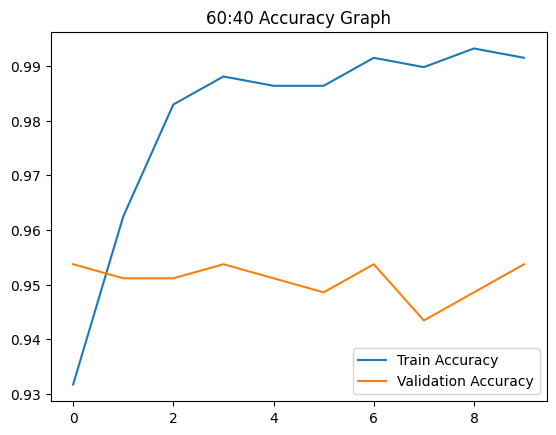

In [13]:
#60%Training and 40% Validation

# ==========================================
# STEP 1: UPLOAD DATASET ZIP FILE
# ==========================================
from google.colab import files
uploaded = files.upload()

# Upload: Mango Dataset.zip


# ==========================================
# STEP 2: EXTRACT ZIP FILE
# ==========================================
import zipfile
zip_path = "Mango Dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("mango_Dataset")

print("Dataset Extracted Successfully!")


# ==========================================
# STEP 3: IMPORT LIBRARIES
# ==========================================
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model


# ==========================================
# STEP 4: COUNT MANGO IMAGES IN DATASET
# ==========================================
dataset_dir = "mango_Dataset"

classes = ['OverRipe', 'Ripe', 'UnRipe']

print("\nMANGO IMAGE COUNT:")
total = 0
for cls in classes:
    count = len(os.listdir(os.path.join(dataset_dir, cls)))
    total += count
    print(f"{cls}: {count}")

print("Total Images:", total)


# ==========================================
# STEP 5: CONFIGURATION
# ==========================================
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 10
MODEL_PATH = "mango_model_60_40.h5"


# ==========================================
# STEP 6: DATA GENERATOR (60:40)
# ==========================================
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.4
)

train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

CLASSES = list(train_data.class_indices.keys())


# ==========================================
# STEP 7: LOAD MOBILENETV2
# ==========================================
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False


# ==========================================
# STEP 8: BUILD MODEL
# ==========================================
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(len(CLASSES), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)


# ==========================================
# STEP 9: COMPILE MODEL
# ==========================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# ==========================================
# STEP 10: TRAIN MODEL
# ==========================================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)


# ==========================================
# STEP 11: SAVE MODEL
# ==========================================
model.save(MODEL_PATH)
print("Model Saved Successfully!")


# ==========================================
# STEP 12: PLOT ACCURACY GRAPH
# ==========================================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train Accuracy','Validation Accuracy'])
plt.title("60:40 Accuracy Graph")
plt.show()

Saving NG_38_A.jpg to NG_38_A.jpg
Dataset Extracted Successfully!

MANGO IMAGE COUNT:
OverRipe: 21
Ripe: 43
UnRipe: 911
Total Images: 975
Found 684 images belonging to 3 classes.
Found 291 images belonging to 3 classes.
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.8947 - loss: 0.3924 - val_accuracy: 0.9416 - val_loss: 0.2347
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9708 - loss: 0.0967 - val_accuracy: 0.9485 - val_loss: 0.2476
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.9781 - loss: 0.0697 - val_accuracy: 0.9485 - val_loss: 0.2519
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9795 - loss: 0.0690 - val_accuracy: 0.9519 - val_loss: 0.2912
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9839 - loss: 0.0605 - val_accuracy: 0.9519 - val_loss: 0.2632
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9883 - loss: 0.0469 - val_accuracy: 0.9519 - val_loss: 0.2946
Epoch 7/10
22/22 ━━━━━━━

Model Saved Successfully!


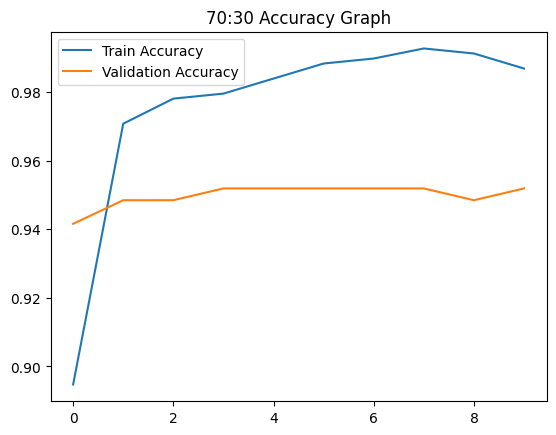

In [14]:
# ==========================================
# STEP 1: UPLOAD DATASET ZIP FILE
# ==========================================
from google.colab import files
uploaded = files.upload()


# ==========================================
# STEP 2: EXTRACT ZIP FILE
# ==========================================
import zipfile
zip_path = "Mango Dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("mango_Dataset")

print("Dataset Extracted Successfully!")


# ==========================================
# STEP 3: IMPORT LIBRARIES
# ==========================================
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


# ==========================================
# STEP 4: COUNT MANGO IMAGES
# ==========================================
dataset_dir = "mango_Dataset"

classes = ['OverRipe', 'Ripe', 'UnRipe']

print("\nMANGO IMAGE COUNT:")
total = 0
for cls in classes:
    count = len(os.listdir(os.path.join(dataset_dir, cls)))
    total += count
    print(f"{cls}: {count}")

print("Total Images:", total)


# ==========================================
# STEP 5: CONFIG
# ==========================================
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 10
MODEL_PATH = "mango_model_70_30.h5"


# ==========================================
# STEP 6: DATA GENERATOR (70:30)
# ==========================================
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.3
)

train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

CLASSES = list(train_data.class_indices.keys())


# ==========================================
# STEP 7: LOAD MOBILENETV2
# ==========================================
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False


# ==========================================
# STEP 8: BUILD MODEL
# ==========================================
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(len(CLASSES), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)


# ==========================================
# STEP 9: COMPILE MODEL
# ==========================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# ==========================================
# STEP 10: TRAIN MODEL
# ==========================================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)


# ==========================================
# STEP 11: SAVE MODEL
# ==========================================
model.save(MODEL_PATH)
print("Model Saved Successfully!")


# ==========================================
# STEP 12: PLOT GRAPH
# ==========================================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train Accuracy','Validation Accuracy'])
plt.title("70:30 Accuracy Graph")
plt.show()

Which split is usually best out of these three Training and Validation Splits?

80:20 usually gives best accuracy
Because,
More training data that is 80% data is used for learning.

So model sees more mango images and learns better patterns.

